# 06 — Observing conditions and the link to optical aberration

Produces:
* `fig/score_vs_conditions.pdf` (`fig:conditions`) — visit-median shapelet score against
  sky background, AOS FWHM and donut-blur FWHM, for both epochs.
* `fig/score_vs_zernike.pdf` (`fig:zernike`) — shapelet score against the peak-to-peak
  spread of each AOS wavefront Zernike coefficient across the four corner sensors.

The Zernike figure is the paper's evidence that the score responds to real optical
aberration measured by an independent instrument.

In [1]:
import importlib.util
spec = importlib.util.spec_from_file_location('plot_config', 'plot_config.py')
plot_config = importlib.util.module_from_spec(spec); spec.loader.exec_module(plot_config)
from plot_config import (BANDS, PALETTE, TIER_EDGES, TIER_COLORS, FIG, DATA,
                         AOS_DETECTORS, ZERNIKE_MODES, MultipleLocator, apply_style,
                         bvec_path, shapelet_score, TAG_VISIT_INFO)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.stats import spearmanr

apply_style()
EPOCHS = {'DP2': 'dp2all', 'Post-DP2': 'postdp2'}

def visit_scores(tag):
    """Median shapelet score per (visit_id, band), all bands."""
    out = []
    for band in BANDS:
        d = np.load(bvec_path(band, tag))
        out.append(pd.DataFrame(dict(visit_id=d['visit'].astype(np.int64),
                                     band=band,
                                     score=shapelet_score(d['bvec']))))
    df = pd.concat(out, ignore_index=True)
    return df.groupby(['visit_id', 'band'], as_index=False)['score'].median()

vs = {e: visit_scores(t) for e, t in EPOCHS.items()}
print({e: len(v) for e, v in vs.items()})

{'DP2': 29502, 'Post-DP2': 41513}


## Score vs observing conditions

In [2]:
COND = [('sky_bg', 'sky background (ADU)'),
        ('aos_fwhm', 'AOS FWHM (arcsec)'),
        ('donut_blur_fwhm', 'donut blur FWHM (arcsec)')]

merged = {}
for epoch, tag in EPOCHS.items():
    info = pd.read_parquet(TAG_VISIT_INFO[tag],
                           columns=['visit_id', 'band'] + [c for c, _ in COND])
    info['visit_id'] = info['visit_id'].astype(np.int64)
    m = vs[epoch].merge(info, on=['visit_id', 'band'], how='inner')
    merged[epoch] = m
    print(f'{epoch}: {len(m):,} visits matched  ' +
          '  '.join(f'{c}:{m[c].notna().sum():,}' for c, _ in COND))

DP2: 29,502 visits matched  sky_bg:29,500  aos_fwhm:28,947  donut_blur_fwhm:22,758
Post-DP2: 41,513 visits matched  sky_bg:38,903  aos_fwhm:38,859  donut_blur_fwhm:38,859


In [3]:
print('Spearman correlation of visit-median score with each condition:')
corr = {}
for epoch in EPOCHS:
    m = merged[epoch]
    for c, _ in COND:
        ok = m[c].notna() & m['score'].notna()
        rho = spearmanr(m.loc[ok, c], m.loc[ok, 'score']).statistic
        corr[(epoch, c)] = (rho, ok.sum())
        print(f'  {epoch:>9} {c:18s} rho = {rho:+.3f}   N = {ok.sum():,}')

Spearman correlation of visit-median score with each condition:
        DP2 sky_bg             rho = +0.121   N = 29,500
        DP2 aos_fwhm           rho = +0.445   N = 28,947
        DP2 donut_blur_fwhm    rho = -0.325   N = 22,758
   Post-DP2 sky_bg             rho = +0.220   N = 38,903
   Post-DP2 aos_fwhm           rho = +0.249   N = 38,859
   Post-DP2 donut_blur_fwhm    rho = -0.568   N = 38,859


wrote /sdf/data/rubin/user/ztq1996/psf-rubin/psf_zernike/shapelet_score_paper/fig/score_vs_conditions.pdf


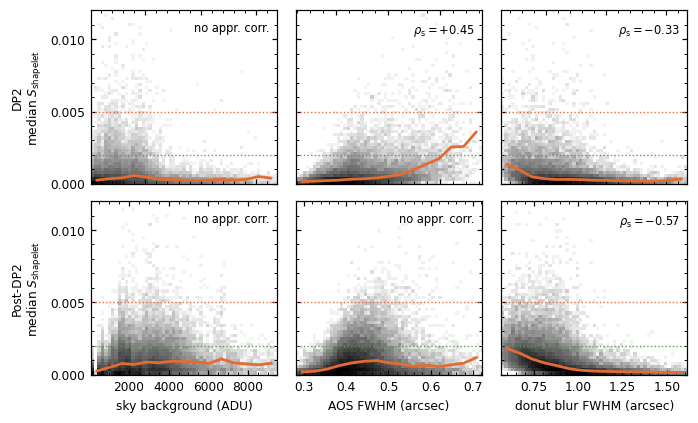

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(7.0, 4.3),
                         gridspec_kw=dict(hspace=0.10, wspace=0.10))

for i, (epoch, _) in enumerate(EPOCHS.items()):
    m = merged[epoch]
    for j, (c, lab) in enumerate(COND):
        ax = axes[i, j]
        ok = m[c].notna() & m['score'].notna() & (m['score'] > 0)
        x, y = m.loc[ok, c].values, m.loc[ok, 'score'].values
        xhi = np.percentile(x, 99)
        sel = x <= xhi
        h = ax.hist2d(x[sel], y[sel], bins=(55, 55),
                      range=((np.percentile(x, 0.5), xhi), (0, 0.012)),
                      norm=LogNorm(), cmap='Greys')
        # running median
        edges = np.linspace(np.percentile(x, 0.5), xhi, 16)
        mid = 0.5 * (edges[:-1] + edges[1:])
        med = [np.median(y[(x >= a) & (x < b)]) if ((x >= a) & (x < b)).sum() > 30
               else np.nan for a, b in zip(edges[:-1], edges[1:])]
        ax.plot(mid, med, color=PALETTE[0], lw=1.8)
        for e, name in zip(TIER_EDGES[:2], ['MEDIUM', 'HIGH']):
            ax.axhline(e, color=TIER_COLORS[name], ls=':', lw=0.9)
        # Annotate the rank correlation only where it reaches |rho| = 0.3;
        # below that the paper describes the relation qualitatively (see the
        # convention stated at the start of the Results section).
        rho = corr[(epoch, c)][0]
        ax.text(0.96, 0.93,
                rf'$\rho_{{\rm s}}={rho:+.2f}$' if abs(rho) >= 0.3 else 'no appr. corr.',
                transform=ax.transAxes, ha='right', va='top', fontsize=7.5)
        if i == 0:
            ax.set_xticklabels([])
        else:
            ax.set_xlabel(lab, fontsize=8)
        if j == 0:
            ax.set_ylabel(f'{epoch}\nmedian $S_{{\\rm shapelet}}$', fontsize=8)
        else:
            ax.set_yticklabels([])
        ax.yaxis.set_minor_locator(MultipleLocator(0.001))
        ax.yaxis.set_major_locator(MultipleLocator(0.005))

fig.savefig(FIG / 'score_vs_conditions.pdf')
print('wrote', FIG / 'score_vs_conditions.pdf')

In [5]:
# Diagnostic: is the NEGATIVE correlation with donut_blur_fwhm a dilution effect?
# The score is a fraction of total power, so anything that raises the atmospheric
# (even-m) power lowers the score at fixed optical aberration. If donut_blur_fwhm
# is itself correlated with the delivered PSF size, that would explain the sign.
from plot_config import FWHM_PER_SIGMA

meas = []
for epoch, tag in EPOCHS.items():
    for band in BANDS:
        d = np.load(bvec_path(band, tag))
        meas.append(pd.DataFrame(dict(epoch=epoch, visit_id=d['visit'].astype(np.int64),
                                      band=band,
                                      fwhm=d['sigma'] * FWHM_PER_SIGMA)))
meas = pd.concat(meas, ignore_index=True)
meas = meas.groupby(['epoch', 'visit_id', 'band'], as_index=False)['fwhm'].median()

print('Spearman correlation of each condition with the MEASURED PSF FWHM:')
for epoch in EPOCHS:
    m = merged[epoch].merge(meas[meas.epoch == epoch][['visit_id', 'band', 'fwhm']],
                            on=['visit_id', 'band'], how='inner')
    for c, _ in COND:
        ok = m[c].notna() & m['fwhm'].notna()
        rho = spearmanr(m.loc[ok, c], m.loc[ok, 'fwhm']).statistic
        print(f'  {epoch:>9} {c:18s} vs measured FWHM: rho = {rho:+.3f}  N = {ok.sum():,}')

Spearman correlation of each condition with the MEASURED PSF FWHM:
        DP2 sky_bg             vs measured FWHM: rho = -0.071  N = 29,500
        DP2 aos_fwhm           vs measured FWHM: rho = +0.367  N = 28,947
        DP2 donut_blur_fwhm    vs measured FWHM: rho = +0.811  N = 22,758
   Post-DP2 sky_bg             vs measured FWHM: rho = -0.026  N = 38,903
   Post-DP2 aos_fwhm           vs measured FWHM: rho = +0.291  N = 38,859
   Post-DP2 donut_blur_fwhm    vs measured FWHM: rho = +0.728  N = 38,859


## Score vs AOS wavefront Zernike spread

The four corner wavefront sensors give an independent estimate of the wavefront at four
points in the field. A large peak-to-peak spread of a Zernike coefficient across those
four positions means the aberration varies strongly over the focal plane, which is
exactly the condition under which we expect the PSF to be visibly asymmetric.

In [6]:
zcols = [f'{z}_{p}' for z in ZERNIKE_MODES for p in AOS_DETECTORS]
zdf = pd.read_parquet(DATA / 'psf_moments_allbands.pq',
                      columns=['visit_id', 'band'] + zcols)
zdf['visit_id'] = zdf['visit_id'].astype(np.int64)

for z in ZERNIKE_MODES:
    arr = zdf[[f'{z}_{p}' for p in AOS_DETECTORS]].values
    zdf[f'{z}_spread'] = np.nanmax(arr, axis=1) - np.nanmin(arr, axis=1)

zm = vs['DP2'].merge(zdf[['visit_id', 'band'] + [f'{z}_spread' for z in ZERNIKE_MODES]],
                     on=['visit_id', 'band'], how='inner')
print(f'matched {len(zm):,} (visit, band) rows with corner Zernikes')

zrho = {}
for z in ZERNIKE_MODES:
    ok = zm[f'{z}_spread'].notna() & zm['score'].notna()
    zrho[z] = spearmanr(zm.loc[ok, f'{z}_spread'], zm.loc[ok, 'score']).statistic
    print(f'  {z:>4}: rho = {zrho[z]:+.3f}   median spread = '
          f'{zm[f"{z}_spread"].median():.3f} um   N = {ok.sum():,}')
best = max(zrho, key=lambda z: abs(zrho[z]))
print(f'\nstrongest: {best} (rho = {zrho[best]:+.3f})')

matched 29,502 (visit, band) rows with corner Zernikes
    z4: rho = +0.063   median spread = 0.264 um   N = 29,502
    z5: rho = +0.028   median spread = 0.594 um   N = 29,502
    z6: rho = +0.092   median spread = 0.647 um   N = 29,502
    z7: rho = +0.170   median spread = 0.340 um   N = 29,502
    z8: rho = +0.201   median spread = 0.251 um   N = 29,502
    z9: rho = +0.070   median spread = 0.230 um   N = 29,502
   z10: rho = +0.101   median spread = 0.255 um   N = 29,502
   z11: rho = +0.076   median spread = 0.124 um   N = 29,502

strongest: z8 (rho = +0.201)


wrote /sdf/data/rubin/user/ztq1996/psf-rubin/psf_zernike/shapelet_score_paper/fig/score_vs_zernike.pdf

mean rho, odd-m Zernikes  = +0.135  (['z7', 'z8', 'z9', 'z10'])
mean rho, even-m Zernikes = +0.065  (['z4', 'z5', 'z6', 'z11'])


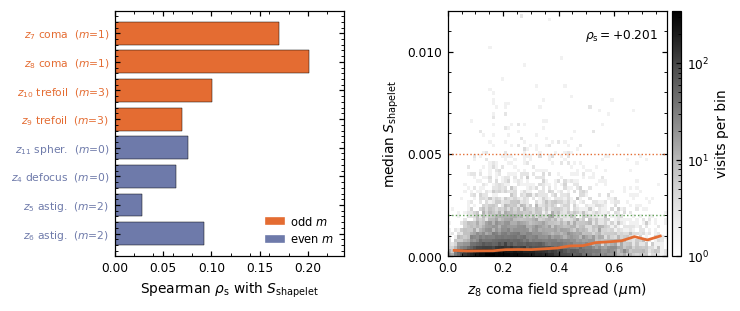

In [7]:
# Noll ordering: the azimuthal order m of each Zernike. The shapelet score is
# built from odd-m shapelet modes, so if it really measures asymmetry it should
# respond preferentially to the ODD-m Zernikes (coma m=1, trefoil m=3) and only
# weakly to the even-m ones (defocus/spherical m=0, astigmatism m=2).
ZERN_M = {'z4': 0, 'z5': 2, 'z6': 2, 'z7': 1, 'z8': 1, 'z9': 3, 'z10': 3, 'z11': 0}
ZLAB = {'z4': r'$z_4$ defocus',   'z5': r'$z_5$ astig.',    'z6': r'$z_6$ astig.',
        'z7': r'$z_7$ coma',      'z8': r'$z_8$ coma',      'z9': r'$z_9$ trefoil',
        'z10': r'$z_{10}$ trefoil', 'z11': r'$z_{11}$ spher.'}
C_ODD, C_EVEN = PALETTE[0], PALETTE[2]

# Order the bars by azimuthal order so the parity split is visible.
zorder = sorted(ZERNIKE_MODES, key=lambda z: (ZERN_M[z] % 2 == 0, ZERN_M[z], z))

fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.9),
                         gridspec_kw=dict(wspace=0.42, width_ratios=[1, 1.15]))

# -- left: correlation with each Zernike's field spread ----------------------
ax = axes[0]
vals = [zrho[z] for z in zorder]
cols = [C_ODD if ZERN_M[z] % 2 else C_EVEN for z in zorder]
ax.barh(np.arange(len(zorder)), vals, color=cols, edgecolor='k', linewidth=0.3)
ax.set_yticks(np.arange(len(zorder)))
ax.set_yticklabels([f'{ZLAB[z]}  ($m$={ZERN_M[z]})' for z in zorder], fontsize=7)
for lab, z in zip(ax.get_yticklabels(), zorder):
    lab.set_color(C_ODD if ZERN_M[z] % 2 else C_EVEN)
ax.invert_yaxis()
ax.axvline(0, color='k', lw=0.6)
ax.set_xlabel(r'Spearman $\rho_{\rm s}$ with $S_{\rm shapelet}$')
ax.set_xlim(0, max(vals) * 1.18)
ax.xaxis.set_minor_locator(MultipleLocator(0.02))
ax.xaxis.set_major_locator(MultipleLocator(0.05))
ax.legend(handles=[plt.Line2D([], [], color=C_ODD, lw=5, label='odd $m$'),
                   plt.Line2D([], [], color=C_EVEN, lw=5, label='even $m$')],
          loc='lower right', frameon=False, fontsize=7.5, handlelength=1.0)

# -- right: 2D histogram for the strongest mode ------------------------------
ax = axes[1]
ok = zm[f'{best}_spread'].notna() & (zm['score'] > 0)
x, y = zm.loc[ok, f'{best}_spread'].values, zm.loc[ok, 'score'].values
xhi = np.percentile(x, 99)
h = ax.hist2d(x, y, bins=(70, 70), range=((0, xhi), (0, 0.012)),
              norm=LogNorm(), cmap='Greys')
edges = np.linspace(0, xhi, 18)
mid = 0.5 * (edges[:-1] + edges[1:])
med = [np.median(y[(x >= a) & (x < b)]) if ((x >= a) & (x < b)).sum() > 30 else np.nan
       for a, b in zip(edges[:-1], edges[1:])]
ax.plot(mid, med, color=PALETTE[0], lw=1.8, label='median')
for e, name in zip(TIER_EDGES[:2], ['MEDIUM', 'HIGH']):
    ax.axhline(e, color=TIER_COLORS[name], ls=':', lw=0.9)
ax.set_xlabel(f'{ZLAB[best]} field spread ' r'($\mu$m)')
ax.set_ylabel(r'median $S_{\rm shapelet}$')
ax.text(0.96, 0.93, rf'$\rho_{{\rm s}}={zrho[best]:+.3f}$', transform=ax.transAxes,
        ha='right', va='top', fontsize=8)
ax.yaxis.set_minor_locator(MultipleLocator(0.001))
ax.yaxis.set_major_locator(MultipleLocator(0.005))
fig.colorbar(h[3], ax=ax, label='visits per bin', pad=0.02, aspect=26)

fig.savefig(FIG / 'score_vs_zernike.pdf')
print('wrote', FIG / 'score_vs_zernike.pdf')

# The headline comparison for the text.
odd = [zrho[z] for z in ZERNIKE_MODES if ZERN_M[z] % 2]
even = [zrho[z] for z in ZERNIKE_MODES if not ZERN_M[z] % 2]
print(f'\nmean rho, odd-m Zernikes  = {np.mean(odd):+.3f}  ({[f"{z}" for z in ZERNIKE_MODES if ZERN_M[z]%2]})')
print(f'mean rho, even-m Zernikes = {np.mean(even):+.3f}  ({[f"{z}" for z in ZERNIKE_MODES if not ZERN_M[z]%2]})')

In [8]:
# Quantify the Zernike trend for the text: median score in the lowest vs highest
# quintile of each Zernike's field spread.
print('median score, lowest -> highest quintile of the field spread:')
for z in zorder:
    ok = zm[f'{z}_spread'].notna() & (zm['score'] > 0)
    x, y = zm.loc[ok, f'{z}_spread'].values, zm.loc[ok, 'score'].values
    q20, q80 = np.percentile(x, [20, 80])
    lo, hi = np.median(y[x <= q20]), np.median(y[x >= q80])
    print(f'  {z:>4} (m={ZERN_M[z]}): {lo:.5f} -> {hi:.5f}  = {hi/lo:.2f}x')

median score, lowest -> highest quintile of the field spread:
    z7 (m=1): 0.00028 -> 0.00058  = 2.05x
    z8 (m=1): 0.00026 -> 0.00062  = 2.35x
   z10 (m=3): 0.00029 -> 0.00045  = 1.53x
    z9 (m=3): 0.00032 -> 0.00044  = 1.40x
   z11 (m=0): 0.00031 -> 0.00042  = 1.38x
    z4 (m=0): 0.00035 -> 0.00048  = 1.35x
    z5 (m=2): 0.00031 -> 0.00034  = 1.10x
    z6 (m=2): 0.00033 -> 0.00047  = 1.42x
